# Pipeline: Stability Selection + Ensemble de Modelos com Stacking

**Etapa 0** — Baseline: modelos individuais + Stacking OOF (split 70/30)  
**Etapa 1** — Stability Selection: cada seletor executado em `B` subamostras de 70% do dataset  
**Etapa 2** — Ensemble de Modelos via Optuna + Stacking OOF por dataset estável

Modelos base: RandomForest · XGBoost · DecisionTree · GaussianNB (calibrado) · KNN · HistGradientBoosting  
Meta-modelo (Stacking): LogisticRegression treinada sobre OOF predictions  
**Voting substituído integralmente por Stability Selection**

In [1]:
# ── Padrão ───────────────────────────────────────────────────────
import warnings
from collections import defaultdict
from pathlib import Path
from statistics import mode as stat_mode

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import Parallel, delayed

# ── Scikit-learn ─────────────────────────────────────────────────
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import (
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
    StackingClassifier,
)
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LassoCV, LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, log_loss,
    matthews_corrcoef, precision_score, recall_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

# ── Optuna ───────────────────────────────────────────────────────
import optuna

# ── XGBoost (opcional) ───────────────────────────────────────────
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠️  XGBoost não disponível — pip install xgboost")

# ── mRMR (opcional) ──────────────────────────────────────────────
try:
    from mrmr import mrmr_classif
    MRMR_AVAILABLE = True
except ImportError:
    MRMR_AVAILABLE = False
    print("⚠️  mRMR não disponível — pip install mrmr-selection")

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)
print("✅ Imports carregados.")


✅ Imports carregados.


## Pré-processamento

IQR capping → remoção de colunas irrelevantes → encode do label.

In [2]:
DATA_PATH = Path("../data/processed/DoS_with_gap_features.csv")
df = pd.read_csv(DATA_PATH)
print(f"Shape original: {df.shape}")

def cap_outliers_iqr(df, columns):
    df_out = df.copy()
    for col in columns:
        q1, q3 = df_out[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        df_out[col] = df_out[col].clip(lower=q1 - 1.5*iqr, upper=q3 + 1.5*iqr)
    return df_out

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df_tratado = cap_outliers_iqr(df, numeric_cols)

COLUNAS_REMOVER = [
    "frame.time_delta_displayed","frame.time_epoch","frame.time_invalid",
    "frame.time_relative","tcp.srcport","tcp.dstport",
    "frame.coloring_rule.name","frame.coloring_rule.string",
    "frame.comment","frame.comment.expert","frame.encap_type",
    "frame.file_off","frame.ignored","frame.incomplete",
    "frame.interface_id","frame.interface_name","frame.link_nr",
    "frame.marked","frame.md5_hash","frame.number","frame.offset_shift",
    "mqtt.msgid","mqtt.username","mqtt.passwd","mqtt.willmsg","mqtt.willtopic",
]

num_df = df_tratado.select_dtypes(include=["int64","float64"])
X = num_df.drop(columns=[c for c in COLUNAS_REMOVER if c in num_df.columns], errors="ignore")
X = X.fillna(0).replace([np.inf, -np.inf], 0)

le = LabelEncoder()
y = le.fit_transform(df_tratado["type"])

print(f"Features: {X.shape[1]} | Amostras: {X.shape[0]}")
print(f"Classes: {le.classes_}  →  {dict(enumerate(le.classes_))}")


Shape original: (94625, 67)
Features: 29 | Amostras: 94625
Classes: ['DoS' 'normal']  →  {0: 'DoS', 1: 'normal'}


## Etapa 0 — Baseline (todos os features, sem seleção)

Split 70/30 estratificado. Sem Optuna, sem seleção de features.  
Modelos individuais + **StackingClassifier OOF** como ensemble (Voting removido).  
Serve de referência para medir o ganho das etapas seguintes.

Treinando modelos baseline…
  ✓ RandomForest          F1=0.9670  LogLoss=0.26702
  ✓ XGBoost               F1=0.9705  LogLoss=0.07812
  ✓ DecisionTree          F1=0.9643  LogLoss=0.58607
  ✓ GaussianNB_Cal        F1=0.9268  LogLoss=0.23611
  ✓ KNN                   F1=0.9654  LogLoss=0.35733
  ✓ GradientBoosting      F1=0.9679  LogLoss=0.08725

Treinando Stacking_OOF baseline…

── Métricas Etapa 0 — Baseline ──────────────────────────


,accuracy,precision,recall,f1_macro,mcc,log_loss
model,,,,,,
RandomForest,0.96713,0.96773,0.96664,0.96705,0.93437,0.26702
XGBoost,0.97055,0.97147,0.96992,0.97047,0.94139,0.07812
DecisionTree,0.96435,0.96439,0.96421,0.96429,0.92860,0.58607
GaussianNB_Cal,0.92754,0.93575,0.92510,0.92682,0.86078,0.23611
KNN,0.96551,0.96580,0.96519,0.96544,0.93099,0.35733
GradientBoosting,0.96805,0.96927,0.96730,0.96795,0.93657,0.08725
Stacking_OOF,0.97083,0.97122,0.97047,0.97077,0.94168,0.08853


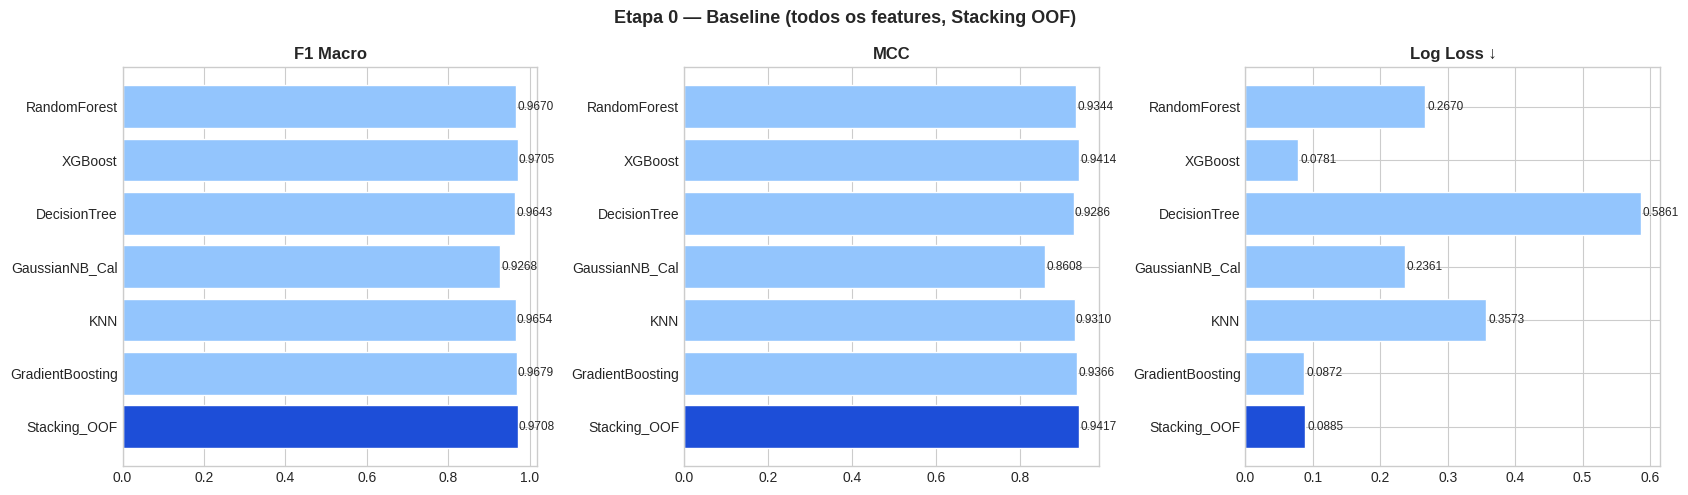


🏆 Melhor baseline: Stacking_OOF  F1=0.97077


In [3]:
# ── Split 70/30 ──────────────────────────────────────────────────
X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

def _metrics(model, X_te, y_te, name):
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te) if hasattr(model, "predict_proba") else None
    ll = log_loss(y_te, y_proba) if y_proba is not None else np.nan
    return {
        "model":     name,
        "accuracy":  round(accuracy_score(y_te, y_pred), 5),
        "precision": round(precision_score(y_te, y_pred, average="macro", zero_division=0), 5),
        "recall":    round(recall_score(y_te, y_pred, average="macro", zero_division=0), 5),
        "f1_macro":  round(f1_score(y_te, y_pred, average="macro", zero_division=0), 5),
        "mcc":       round(matthews_corrcoef(y_te, y_pred), 5),
        "log_loss":  round(ll, 5) if np.isfinite(ll) else np.nan,
    }

BASELINE_MODELS = {
    "RandomForest":     RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "XGBoost":          (XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1,
                                       verbosity=0, eval_metric="logloss")
                         if XGBOOST_AVAILABLE else
                         RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    "DecisionTree":     DecisionTreeClassifier(random_state=42),
    "GaussianNB_Cal":   CalibratedClassifierCV(GaussianNB(), method="isotonic", cv=3),
    "KNN":              KNeighborsClassifier(n_neighbors=7, n_jobs=-1, algorithm="kd_tree"),
    "GradientBoosting": HistGradientBoostingClassifier(max_iter=50, learning_rate=0.1,
                                                       max_depth=4, random_state=42),
}

print("Treinando modelos baseline…")
baseline_rows, baseline_trained = [], {}
for name, model in BASELINE_MODELS.items():
    model.fit(X_tr_b, y_tr_b)
    baseline_trained[name] = model
    row = _metrics(model, X_te_b, y_te_b, name)
    baseline_rows.append(row)
    print(f"  ✓ {name:20s}  F1={row['f1_macro']:.4f}  LogLoss={row['log_loss']}")

# ── Stacking OOF (substitui VotingClassifier) ─────────────────────
# cv=3 suficiente para OOF estável, passthrough=False → meta-modelo
# recebe apenas predições dos base models (M+1 parâmetros = compacto).
print("\nTreinando Stacking_OOF baseline…")
stk_base = [(n, clone(m)) for n, m in BASELINE_MODELS.items()]
stk = StackingClassifier(
    estimators=stk_base,
    final_estimator=LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    cv=3, passthrough=False, n_jobs=-1,
)
stk.fit(X_tr_b, y_tr_b)
baseline_rows.append(_metrics(stk, X_te_b, y_te_b, "Stacking_OOF"))

df_baseline = pd.DataFrame(baseline_rows).set_index("model")
print("\n── Métricas Etapa 0 — Baseline ──────────────────────────")
display(df_baseline)

# ── Gráfico ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
colors_b = ["#1D4ED8" if m == "Stacking_OOF" else "#93C5FD" for m in df_baseline.index]
for ax, col, lbl in zip(axes, ["f1_macro","mcc","log_loss"],
                                ["F1 Macro","MCC","Log Loss ↓"]):
    bars = ax.barh(df_baseline.index, df_baseline[col], color=colors_b, edgecolor="white")
    ax.invert_yaxis()
    ax.set_title(lbl, fontweight="bold")
    for bar, v in zip(bars, df_baseline[col]):
        ax.text(bar.get_width()+0.003, bar.get_y()+bar.get_height()/2,
                f"{v:.4f}" if np.isfinite(v) else "N/A", va="center", fontsize=8.5)
plt.suptitle("Etapa 0 — Baseline (todos os features, Stacking OOF)",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

best_b = df_baseline["f1_macro"].idxmax()
print(f"\n🏆 Melhor baseline: {best_b}  F1={df_baseline.loc[best_b,'f1_macro']:.5f}")


## Etapa 1 — Stability Selection

**Stability Selection** (Meinshausen & Bühlmann, 2010) substitui o voting por consenso.

Para cada um dos 7 seletores, executa `N_BOOTSTRAPS` subamostras aleatórias de **70%** do dataset sem reposição.  
A frequência de seleção de cada feature é acumulada. Features com frequência ≥ `STABILITY_THRESHOLD` são consideradas **estáveis**.

Três estratégias de consenso entre seletores:

| Dataset | Critério |
|---|---|
| Por seletor | Features estáveis individualmente para aquele seletor |
| `consensus_stable` | Features estáveis em **todos** os seletores (freq_média ≥ threshold) |
| `consensus_top15_stable` | Top-15 features por score de estabilidade médio entre seletores |

In [4]:
# ── Parâmetros de seleção ─────────────────────────────────────────
K_MRMR = K_FISHER = K_PEARSON = K_TREE = K_SVC = K_LASSO = 15

# ── Parâmetros de Stability Selection ────────────────────────────
N_BOOTSTRAPS       = 100   # número de subamostras por seletor
SUBSAMPLE_RATIO    = 0.70  # fração do dataset em cada bootstrap
STABILITY_THRESHOLD = 0.60 # frequência mínima para feature "estável"
RANDOM_STATE       = 42

rng = np.random.default_rng(RANDOM_STATE)

# ── Fisher Score ─────────────────────────────────────────────────
def fisher_score(X, y):
    classes      = np.unique(y)
    overall_mean = X.mean(axis=0).values
    scores       = np.zeros(X.shape[1])
    for i in range(X.shape[1]):
        vals = X.iloc[:, i].values
        bet, wit = 0.0, 0.0
        for c in classes:
            mask = y == c; nc = mask.sum()
            if nc > 0:
                mu_c = vals[mask].mean()
                bet += nc * (mu_c - overall_mean[i])**2
                wit += nc * vals[mask].var()
        scores[i] = bet / wit if wit > 1e-10 else 0.0
    return scores

# ── Funções base de seleção ───────────────────────────────────────
def _selector_functions():
    def sel_mrmr(X_tr, y_tr):
        if not MRMR_AVAILABLE: return []
        try: return mrmr_classif(X_tr, y_tr, K=min(K_MRMR, X_tr.shape[1]))
        except Exception as e: return []

    def sel_fisher(X_tr, y_tr):
        sc = fisher_score(X_tr, y_tr)
        return (pd.DataFrame({"f": X_tr.columns, "s": sc})
                .sort_values("s", ascending=False)
                .head(min(K_FISHER, len(X_tr.columns)))["f"].tolist())

    def sel_pearson(X_tr, y_tr):
        ac = X_tr.apply(lambda c: abs(np.corrcoef(c, y_tr)[0,1])).fillna(0)
        return ac.sort_values(ascending=False).head(min(K_PEARSON, len(ac))).index.tolist()

    def sel_extratrees(X_tr, y_tr):
        et = ExtraTreesClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
        et.fit(X_tr, y_tr)
        imp = pd.Series(et.feature_importances_, index=X_tr.columns)
        return imp.sort_values(ascending=False).head(min(K_TREE, X_tr.shape[1])).index.tolist()

    def sel_svc(X_tr, y_tr):
        Xs = StandardScaler().fit_transform(X_tr)
        svc = LinearSVC(C=0.1, penalty="l1", dual=False, max_iter=5000, random_state=RANDOM_STATE)
        svc.fit(Xs, y_tr)
        coef = np.mean(np.abs(svc.coef_), axis=0) if svc.coef_.ndim > 1 else np.abs(svc.coef_[0])
        return (pd.Series(coef, index=X_tr.columns)
                .sort_values(ascending=False).head(min(K_SVC, X_tr.shape[1])).index.tolist())

    def sel_lasso(X_tr, y_tr):
        Xs = StandardScaler().fit_transform(X_tr)
        lasso = LassoCV(cv=3, random_state=RANDOM_STATE, max_iter=10000, n_jobs=-1)
        lasso.fit(Xs, y_tr)
        return (pd.Series(np.abs(lasso.coef_), index=X_tr.columns)
                .sort_values(ascending=False).head(min(K_LASSO, X_tr.shape[1])).index.tolist())

    def sel_lowvar(X_tr, y_tr):
        sel = VarianceThreshold(threshold=0.0); sel.fit(X_tr)
        return X_tr.columns[sel.get_support(indices=True)].tolist()

    return {
        "mRMR":         sel_mrmr,
        "Fisher":       sel_fisher,
        "Pearson":      sel_pearson,
        "ExtraTrees":   sel_extratrees,
        "LinearSVC_L1": sel_svc,
        "LassoCV":      sel_lasso,
        "LowVariance":  sel_lowvar,
    }

selector_funcs = _selector_functions()
print("Seletores:", list(selector_funcs.keys()))

# ── Stability Selection ───────────────────────────────────────────
def run_stability_selection(X, y, selector_fns,
                             n_bootstraps=N_BOOTSTRAPS,
                             subsample_ratio=SUBSAMPLE_RATIO,
                             threshold=STABILITY_THRESHOLD,
                             seed=RANDOM_STATE):
    """
    Para cada seletor, executa n_bootstraps subamostras sem reposição
    de tamanho int(n * subsample_ratio). Acumula frequência de seleção
    por feature. Retorna:
        freq_table : DataFrame (features × seletores) com frequências [0,1]
        stable_sets: {selector: [features com freq >= threshold]}
    """
    n = len(y)
    n_sub = int(n * subsample_ratio)
    rng_local = np.random.default_rng(seed)
    all_features = X.columns.tolist()

    # Contadores: {selector: {feature: int}}
    counts = {sel: defaultdict(int) for sel in selector_fns}

    print(f"Stability Selection: {n_bootstraps} bootstraps × {subsample_ratio:.0%} = "
          f"{n_sub} amostras por iteração")

    for b in range(n_bootstraps):
        if (b + 1) % 20 == 0:
            print(f"  bootstrap {b+1}/{n_bootstraps}…")
        idx = rng_local.choice(n, n_sub, replace=False)
        X_sub = X.iloc[idx].reset_index(drop=True)
        y_sub = y[idx]

        for sel_name, sel_fn in selector_fns.items():
            try:
                cols = sel_fn(X_sub, y_sub)
                for col in cols:
                    counts[sel_name][col] += 1
            except Exception:
                pass  # bootstrap em subsample pode falhar em casos extremos

    # Frequências de seleção
    freq_data = {
        sel: {feat: counts[sel].get(feat, 0) / n_bootstraps for feat in all_features}
        for sel in selector_fns
    }
    freq_table = pd.DataFrame(freq_data, index=all_features)

    # Conjuntos estáveis por seletor
    stable_sets = {
        sel: sorted(
            [f for f in all_features if freq_data[sel][f] >= threshold],
            key=lambda f: -freq_data[sel][f],
        )
        for sel in selector_fns
    }

    return freq_table, stable_sets


print("Executando Stability Selection sobre X completo…")
freq_table, stable_sets = run_stability_selection(X, y, selector_funcs)

print("\n── Conjuntos estáveis por seletor ───────────────────────")
for sel, feats in stable_sets.items():
    print(f"  {sel:15s} → {len(feats):2d} features: {feats}")

# ── Score de estabilidade médio (consenso) ───────────────────────
freq_table["mean_stability"] = freq_table.mean(axis=1)
freq_table["n_stable_selectors"] = (freq_table[list(selector_funcs.keys())] >= STABILITY_THRESHOLD).sum(axis=1)
freq_table_sorted = freq_table.sort_values(
    ["n_stable_selectors", "mean_stability"], ascending=[False, False]
)

print("\n── Top 20 features por estabilidade média ───────────────")
display(freq_table_sorted[["n_stable_selectors","mean_stability"] +
                            list(selector_funcs.keys())].head(20).round(3))

# ── Gera datasets ─────────────────────────────────────────────────
selector_datasets = {}

# Um dataset por seletor (features estáveis para aquele seletor)
for sel_name, feats in stable_sets.items():
    if feats:
        selector_datasets[sel_name] = X[feats].copy()

# Consenso: features com mean_stability >= threshold em TODOS os seletores
consensus_stable_cols = freq_table_sorted[
    freq_table_sorted["n_stable_selectors"] == len(selector_funcs)
].index.tolist()
if not consensus_stable_cols:
    # fallback: n_stable_selectors >= maioria
    consensus_stable_cols = freq_table_sorted[
        freq_table_sorted["n_stable_selectors"] >= len(selector_funcs) // 2 + 1
    ].index.tolist()
    print(f"  ⚠ consensus_stable: nenhuma feature universal, usando maioria ({len(consensus_stable_cols)} features)")

selector_datasets["consensus_stable"] = X[consensus_stable_cols].copy()

# Consenso top-15 por mean_stability
consensus_top15_cols = freq_table_sorted.head(15).index.tolist()
selector_datasets["consensus_top15_stable"] = X[consensus_top15_cols].copy()

print(f"\nDatasets gerados ({len(selector_datasets)}):")
for k, v in selector_datasets.items():
    print(f"  {k:25s} → {v.shape[1]:2d} features")


Seletores: ['mRMR', 'Fisher', 'Pearson', 'ExtraTrees', 'LinearSVC_L1', 'LassoCV', 'LowVariance']
Executando Stability Selection sobre X completo…
Stability Selection: 100 bootstraps × 70% = 66237 amostras por iteração


100%|██████████| 14/14 [00:03<00:00,  4.53it/s]


  bootstrap 20/100…


100%|██████████| 14/14 [00:02<00:00,  5.36it/s]


  bootstrap 40/100…


...

  bootstrap 100/100…


100%|██████████| 14/14 [00:02<00:00,  5.30it/s]



── Conjuntos estáveis por seletor ───────────────────────
  mRMR            → 14 features: ['frame.time_delta', 'frame.cap_len', 'frame.len', 'mqtt.clientid_len', 'mqtt.conack.flags.reserved', 'mqtt.conack.flags.sp', 'mqtt.conack.val', 'mqtt.conflag.cleansess', 'mqtt.kalive', 'mqtt.len', 'mqtt.msgtype', 'mqtt.topic_len', 'publish_gap', 'connect_gap']
  Fisher          → 15 features: ['frame.time_delta', 'frame.cap_len', 'frame.len', 'mqtt.clientid_len', 'mqtt.conack.flags.reserved', 'mqtt.conack.flags.sp', 'mqtt.conack.val', 'mqtt.conflag.cleansess', 'mqtt.conflag.uname', 'mqtt.kalive', 'mqtt.len', 'mqtt.msgtype', 'mqtt.topic_len', 'publish_gap', 'connect_gap']
  Pearson         → 15 features: ['frame.time_delta', 'frame.cap_len', 'frame.len', 'mqtt.clientid_len', 'mqtt.conack.flags.reserved', 'mqtt.conack.flags.sp', 'mqtt.conack.val', 'mqtt.conflag.cleansess', 'mqtt.conflag.uname', 'mqtt.kalive', 'mqtt.len', 'mqtt.msgtype', 'mqtt.topic_len', 'publish_gap', 'connect_gap']
  ExtraTrees

,n_stable_selectors,mean_stability,mRMR,Fisher,Pearson,ExtraTrees,LinearSVC_L1,LassoCV,LowVariance
frame.time_delta,7,1.000,1.0,1.0,1.0,1.0,1.0,1.0,1.0
frame.cap_len,7,1.000,1.0,1.0,1.0,1.0,1.0,1.0,1.0
frame.len,7,1.000,1.0,1.0,1.0,1.0,1.0,1.0,1.0
mqtt.clientid_len,7,1.000,1.0,1.0,1.0,1.0,1.0,1.0,1.0
mqtt.conack.flags.reserved,7,1.000,1.0,1.0,1.0,1.0,1.0,1.0,1.0
mqtt.conack.flags.sp,7,1.000,1.0,1.0,1.0,1.0,1.0,1.0,1.0
mqtt.conack.val,7,1.000,1.0,1.0,1.0,1.0,1.0,1.0,1.0
mqtt.conflag.cleansess,7,1.000,1.0,1.0,1.0,1.0,1.0,1.0,1.0
mqtt.len,7,1.000,1.0,1.0,1.0,1.0,1.0,1.0,1.0
mqtt.topic_len,7,1.000,1.0,1.0,1.0,1.0,1.0,1.0,1.0



Datasets gerados (9):
  mRMR                      → 14 features
  Fisher                    → 15 features
  Pearson                   → 15 features
  ExtraTrees                → 15 features
  LinearSVC_L1              → 15 features
  LassoCV                   → 15 features
  LowVariance               → 14 features
  consensus_stable          → 12 features
  consensus_top15_stable    → 15 features


### Visualizações — Stability Selection

In [ ]:
# ── 1. Heatmap de frequências: features × seletores (Top 20) ─────
top20 = freq_table_sorted.head(20).index.tolist()
heat = freq_table.loc[top20, list(selector_funcs.keys())]

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(heat.T, annot=True, fmt=".2f", cmap="Blues",
            vmin=0, vmax=1, linewidths=0.4, ax=axes[0],
            cbar_kws={"label": "Frequência de seleção"})
axes[0].axhline(y=0, color="black", linewidth=0)
axes[0].set_title(f"Stability Selection — Frequências (threshold={STABILITY_THRESHOLD})",
                  fontweight="bold")
axes[0].set_xlabel("Feature")
axes[0].set_ylabel("Seletor")
axes[0].tick_params(axis="x", rotation=45)

# Marca o threshold com linha tracejada horizontal no heatmap
for ax_val in np.arange(0, heat.shape[1]+1):
    axes[0].axvline(ax_val, color="white", linewidth=0.5)

# ── 2. Bar chart: mean_stability por feature ──────────────────────
ms = freq_table_sorted.loc[top20, "mean_stability"]
n_sel = freq_table_sorted.loc[top20, "n_stable_selectors"]
colors_ms = [
    "#1D4ED8" if v == len(selector_funcs) else
    "#3B82F6" if v >= len(selector_funcs) * 0.7 else
    "#93C5FD" if v >= len(selector_funcs) * 0.5 else
    "#DBEAFE"
    for v in n_sel
]
bars = axes[1].barh(top20, ms, color=colors_ms, edgecolor="white")
axes[1].invert_yaxis()
axes[1].axvline(STABILITY_THRESHOLD, color="#F59E0B", linewidth=1.8,
                linestyle="--", label=f"Threshold={STABILITY_THRESHOLD}")
axes[1].set_xlabel("Estabilidade média entre seletores")
axes[1].set_title("Mean Stability Score — Top 20 features", fontweight="bold")
axes[1].legend()
for bar, v, n in zip(bars, ms, n_sel):
    axes[1].text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2,
                 f"{v:.2f} ({int(n)}/{len(selector_funcs)})",
                 va="center", fontsize=8)

plt.tight_layout(); plt.show()

# ── 3. Heatmap binário: estável (1) / instável (0) ────────────────
fig, ax = plt.subplots(figsize=(14, 6))
stable_matrix = (freq_table.loc[top20, list(selector_funcs.keys())] >= STABILITY_THRESHOLD).astype(int)
sns.heatmap(stable_matrix.T, annot=True, fmt="d", cmap="Blues",
            cbar=False, linewidths=0.4, ax=ax)
ax.set_title(f"Mapa Binário de Estabilidade (1 = freq ≥ {STABILITY_THRESHOLD})",
             fontweight="bold")
ax.set_xlabel("Feature"); ax.set_ylabel("Seletor")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

# ── 4. Resumo dos datasets ─────────────────────────────────────────
print("\n── Resumo dos datasets estáveis ──────────────────────────")
for name, ds in selector_datasets.items():
    print(f"  {name:25s} → {ds.shape[1]:2d} features")
    print(f"    {ds.columns.tolist()}")


## Etapa 2 — Ensemble de Modelos com Optuna + Stacking OOF

Para cada dataset da Etapa 1, executa validação cruzada estratificada de 5 folds.  
Dentro de cada fold:

1. **Stability Selection no X_tr do fold** (`N_BOOTSTRAPS_FOLD` subamostras de 70%) → features estáveis do fold
2. **Optuna** (20 trials, 3-fold CV interno) → tuna 6 modelos em paralelo
3. **StackingClassifier OOF** (cv=3) → meta-modelo LogisticRegression

A Stability Selection dentro de cada fold evita data leakage do conjunto de validação para a seleção de features.

In [ ]:
def _to_array(X):
    return X.values if isinstance(X, pd.DataFrame) else X

# ── RandomForest ─────────────────────────────────────────────────
def _obj_rf(trial, X_tr, y_tr):
    p = {"n_estimators": trial.suggest_int("n_estimators", 50, 400, step=50),
         "max_depth":    trial.suggest_categorical("max_depth", [None, 5, 10, 20, 30]),
         "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
         "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 1, 10),
         "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
         "bootstrap":    trial.suggest_categorical("bootstrap", [True, False]),
         "random_state": 42, "n_jobs": -1}
    return cross_val_score(RandomForestClassifier(**p), _to_array(X_tr), y_tr,
                           cv=3, scoring="f1_macro", n_jobs=-1).mean()

# ── XGBoost ──────────────────────────────────────────────────────
def _obj_xgb(trial, X_tr, y_tr):
    p = {"n_estimators":     trial.suggest_int("n_estimators", 50, 400, step=50),
         "max_depth":        trial.suggest_int("max_depth", 2, 10),
         "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
         "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
         "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
         "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
         "gamma":            trial.suggest_float("gamma", 0.0, 1.0),
         "reg_alpha":        trial.suggest_float("reg_alpha", 1e-5, 1.0, log=True),
         "reg_lambda":       trial.suggest_float("reg_lambda", 1e-5, 1.0, log=True),
         "random_state": 42, "n_jobs": -1, "verbosity": 0, "eval_metric": "logloss"}
    mdl = (XGBClassifier(**p) if XGBOOST_AVAILABLE
           else RandomForestClassifier(random_state=42, n_jobs=-1))
    return cross_val_score(mdl, _to_array(X_tr), y_tr,
                           cv=3, scoring="f1_macro", n_jobs=-1).mean()

# ── DecisionTree ─────────────────────────────────────────────────
def _obj_dt(trial, X_tr, y_tr):
    p = {"max_depth":    trial.suggest_categorical("max_depth", [None, 3, 5, 10, 20]),
         "min_samples_split": trial.suggest_int("min_samples_split", 2, 30),
         "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 1, 15),
         "criterion":    trial.suggest_categorical("criterion", ["gini", "entropy"]),
         "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
         "splitter":     trial.suggest_categorical("splitter", ["best", "random"]),
         "random_state": 42}
    return cross_val_score(DecisionTreeClassifier(**p), _to_array(X_tr), y_tr,
                           cv=3, scoring="f1_macro", n_jobs=-1).mean()

# ── GaussianNB calibrado ─────────────────────────────────────────
def _obj_gnb(trial, X_tr, y_tr):
    vs = trial.suggest_float("var_smoothing", 1e-11, 1e-5, log=True)
    cm = trial.suggest_categorical("calibration_method", ["sigmoid", "isotonic"])
    mdl = CalibratedClassifierCV(GaussianNB(var_smoothing=vs), method=cm, cv=3)
    return cross_val_score(mdl, _to_array(X_tr), y_tr,
                           cv=3, scoring="f1_macro", n_jobs=-1).mean()

def _build_gnb(**p):
    return CalibratedClassifierCV(GaussianNB(var_smoothing=p["var_smoothing"]),
                                  method=p.get("calibration_method", "isotonic"), cv=3)

# ── KNN ──────────────────────────────────────────────────────────
def _obj_knn(trial, X_tr, y_tr):
    p = {"n_neighbors": trial.suggest_int("n_neighbors", 1, 50),
         "weights":     trial.suggest_categorical("weights", ["uniform", "distance"]),
         "metric":      trial.suggest_categorical("metric", ["euclidean", "manhattan", "minkowski"]),
         "p":           trial.suggest_int("p", 1, 3), "n_jobs": -1}
    return cross_val_score(KNeighborsClassifier(**p), _to_array(X_tr), y_tr,
                           cv=3, scoring="f1_macro", n_jobs=-1).mean()

# ── HistGradientBoosting ─────────────────────────────────────────
def _obj_gb(trial, X_tr, y_tr):
    p = {"max_iter":          trial.suggest_int("max_iter", 50, 300, step=50),
         "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
         "max_depth":         trial.suggest_int("max_depth", 2, 8),
         "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 1, 50),
         "l2_regularization": trial.suggest_float("l2_regularization", 1e-4, 1.0, log=True),
         "max_bins":          trial.suggest_categorical("max_bins", [63, 127, 255]),
         "random_state": 42}
    return cross_val_score(HistGradientBoostingClassifier(**p), _to_array(X_tr), y_tr,
                           cv=3, scoring="f1_macro", n_jobs=-1).mean()

MODEL_OBJECTIVES = {
    "RandomForest":     (_obj_rf,  RandomForestClassifier,         {"random_state":42, "n_jobs":-1}),
    "XGBoost":          (_obj_xgb, XGBClassifier if XGBOOST_AVAILABLE else RandomForestClassifier,
                         {"random_state":42,"n_jobs":-1,"verbosity":0,"eval_metric":"logloss"}
                         if XGBOOST_AVAILABLE else {"random_state":42,"n_jobs":-1}),
    "DecisionTree":     (_obj_dt,  DecisionTreeClassifier,         {"random_state":42}),
    "GaussianNB_Cal":   (_obj_gnb, _build_gnb,                     {}),
    "KNN":              (_obj_knn, KNeighborsClassifier,            {"n_jobs":-1}),
    "GradientBoosting": (_obj_gb,  HistGradientBoostingClassifier,  {"random_state":42}),
}
print("Modelos Optuna:", list(MODEL_OBJECTIVES.keys()))


### Pipeline Core — Stability Selection no Fold + Optuna + Stacking OOF

In [ ]:
# ── Número de bootstraps dentro de cada fold (menor para viabilidade) ──
# 30 bootstraps × 70% de 75k amostras = 30 × 52k subamostras por fold
# Suficiente para estabilizar as frequências sem custo excessivo.
N_BOOTSTRAPS_FOLD = 30

# ── Worker Optuna ─────────────────────────────────────────────────
def _tune_one(name, obj_fn, constructor, fixed, X_arr, y_tr, n_trials):
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=5),
    )
    study.optimize(lambda t: obj_fn(t, X_arr, y_tr),
                   n_trials=n_trials, show_progress_bar=False)
    params = {**study.best_params, **fixed}
    return name, constructor(**params), params.copy()


def tune_fold(X_tr, y_tr, n_trials=20):
    """Tuna todos os modelos em paralelo via threading."""
    X_arr = _to_array(X_tr)
    results = Parallel(n_jobs=len(MODEL_OBJECTIVES), backend="threading")(
        delayed(_tune_one)(name, obj, ctor, fixed, X_arr, y_tr, n_trials)
        for name, (obj, ctor, fixed) in MODEL_OBJECTIVES.items()
    )
    return {n: m for n, m, _ in results}, {n: p for n, _, p in results}


def _agg_params(plist):
    if not plist: return {}
    agg = {}
    for key in plist[0]:
        vals = [p[key] for p in plist if p.get(key) is not None]
        if not vals: agg[key] = None
        elif all(isinstance(v, float) for v in vals): agg[key] = float(np.mean(vals))
        elif all(isinstance(v, int)   for v in vals): agg[key] = int(round(np.mean(vals)))
        else:
            raw = stat_mode(str(v) for v in vals)
            agg[key] = {"None": None, "True": True, "False": False}.get(raw, raw)
    return agg


def _compute_metrics(model, X_val, y_val):
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val) if hasattr(model, "predict_proba") else None
    if y_proba is None and hasattr(model, "decision_function"):
        ds = model.decision_function(X_val)
        if ds.ndim == 1: ds = np.vstack([-ds, ds]).T
        y_proba = np.exp(ds) / np.exp(ds).sum(axis=1, keepdims=True)
    ll = np.nan
    if y_proba is not None:
        try: ll = log_loss(y_val, y_proba)
        except: pass
    return {"accuracy":  accuracy_score(y_val, y_pred),
            "precision": precision_score(y_val, y_pred, average="macro", zero_division=0),
            "recall":    recall_score(y_val, y_pred, average="macro", zero_division=0),
            "f1":        f1_score(y_val, y_pred, average="macro", zero_division=0),
            "mcc":       matthews_corrcoef(y_val, y_pred),
            "logloss":   ll}


def _build_fresh(name, params):
    _, constructor, _ = MODEL_OBJECTIVES[name]
    return constructor(**params)


def stability_selection_fold(X_tr, y_tr, selector_fns,
                              n_bootstraps=N_BOOTSTRAPS_FOLD,
                              subsample_ratio=SUBSAMPLE_RATIO,
                              threshold=STABILITY_THRESHOLD,
                              fold_seed=42):
    """
    Stability Selection aplicada ao X_tr de um fold externo.
    Retorna features estáveis por seletor e score médio de estabilidade.
    NUNCA vê X_val — zero data leakage.
    """
    n_tr = len(y_tr)
    n_sub = int(n_tr * subsample_ratio)
    rng_fold = np.random.default_rng(fold_seed)
    all_features = X_tr.columns.tolist()

    counts = {sel: defaultdict(int) for sel in selector_fns}

    for _ in range(n_bootstraps):
        idx = rng_fold.choice(n_tr, n_sub, replace=False)
        X_sub = X_tr.iloc[idx].reset_index(drop=True)
        y_sub = y_tr[idx]
        for sel_name, sel_fn in selector_fns.items():
            try:
                for col in sel_fn(X_sub, y_sub):
                    counts[sel_name][col] += 1
            except Exception:
                pass

    # Frequências
    freqs = {sel: {f: counts[sel].get(f, 0)/n_bootstraps for f in all_features}
             for sel in selector_fns}

    # Mean stability por feature
    mean_stab = {f: np.mean([freqs[sel][f] for sel in selector_fns])
                 for f in all_features}

    # Stable sets: features com freq >= threshold em TODOS os seletores
    # Se o conjunto ficar vazio, usa maioria dos seletores
    n_sel = len(selector_fns)
    universal = [f for f in all_features
                 if all(freqs[sel][f] >= threshold for sel in selector_fns)]
    if not universal:
        # fallback: maioria dos seletores
        universal = [f for f in all_features
                     if sum(freqs[sel][f] >= threshold for sel in selector_fns) > n_sel // 2]
    if not universal:
        # fallback final: top-15 por mean_stability
        universal = sorted(all_features, key=lambda f: -mean_stab[f])[:15]

    return universal, freqs, mean_stab


def evaluate_dataset_cv(ds_name, X_ds, y, cv_splits=5, n_optuna_trials=20):
    """
    CV estratificado para um dataset de features.
    Por fold:
      1. Stability Selection em X_tr do fold (evita leakage)
      2. Optuna → 6 modelos tunados em paralelo
      3. StackingClassifier OOF (cv=3, meta=LogisticRegression)
    Retorna: df_metrics, best_hyperparams, stability_info_per_fold
    """
    skf = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)
    all_m    = defaultdict(lambda: defaultdict(list))
    fold_hp  = defaultdict(list)
    stab_info = []   # frequências de estabilidade por fold (para análise)

    for fold_idx, (tr_idx, val_idx) in enumerate(skf.split(X_ds, y), start=1):
        print(f"  [Fold {fold_idx}/{cv_splits}] {ds_name}…")
        X_tr, X_val = X_ds.iloc[tr_idx], X_ds.iloc[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]

        # ── Stability Selection dentro do fold (sem ver X_val) ──────
        stable_cols, fold_freqs, fold_mean_stab = stability_selection_fold(
            X_tr, y_tr, selector_funcs,
            n_bootstraps=N_BOOTSTRAPS_FOLD,
            subsample_ratio=SUBSAMPLE_RATIO,
            threshold=STABILITY_THRESHOLD,
            fold_seed=42 + fold_idx,
        )
        stab_info.append({"fold": fold_idx, "n_stable": len(stable_cols),
                          "cols": stable_cols})

        X_tr_s  = X_tr[stable_cols]
        X_val_s = X_val[stable_cols]

        # ── Optuna ──────────────────────────────────────────────────
        instances, bp_fold = tune_fold(X_tr_s, y_tr, n_trials=n_optuna_trials)
        for nm, p in bp_fold.items():
            fold_hp[nm].append(p)

        # ── Treina individuais ────────────────────────────────────────
        trained = {}
        for nm, mdl in instances.items():
            mdl.fit(X_tr_s, y_tr)
            trained[nm] = mdl
            for k, v in _compute_metrics(mdl, X_val_s, y_val).items():
                all_m[nm][k].append(v)

        # ── Stacking OOF ─────────────────────────────────────────────
        # Base models com params do fold (instâncias frescas para OOF interno)
        stk_est = [(nm, _build_fresh(nm, bp_fold[nm])) for nm in trained]
        stk = StackingClassifier(
            estimators=stk_est,
            final_estimator=LogisticRegression(max_iter=1000, C=1.0, random_state=42),
            cv=3, passthrough=False, n_jobs=-1,
        )
        stk.fit(X_tr_s, y_tr)
        for k, v in _compute_metrics(stk, X_val_s, y_val).items():
            all_m["Stacking_OOF"][k].append(v)

    # ── Agrega métricas ──────────────────────────────────────────────
    rows = []
    for model_name, md_vals in all_m.items():
        row = {"dataset": ds_name, "model": model_name}
        for metric, vals in md_vals.items():
            finite = [v for v in vals if np.isfinite(v)]
            row[f"{metric}_mean"] = float(np.mean(finite)) if finite else np.nan
            row[f"{metric}_std"]  = float(np.std(finite))  if finite else np.nan
        rows.append(row)

    best_hp = {nm: _agg_params(plist) for nm, plist in fold_hp.items()}
    return pd.DataFrame(rows), best_hp, stab_info

print("✅ Pipeline core definido.")


### Orquestração, Visualização e Comparação Final

In [ ]:
# ── Gráfico por dataset ───────────────────────────────────────────
def plot_dataset_results(df_res, title):
    if df_res.empty: return
    METRICS = [("accuracy_mean","Accuracy"),("precision_mean","Precision"),
               ("recall_mean","Recall"),("f1_mean","F1 Macro"),
               ("mcc_mean","MCC"),("logloss_mean","Log Loss ↓")]
    colors = ["#1D4ED8" if m == "Stacking_OOF" else "#93C5FD" for m in df_res["model"]]
    ncols, nrows = 3, int(np.ceil(len(METRICS)/3))
    fig, axes = plt.subplots(nrows, ncols, figsize=(17, 4.5*nrows))
    axes = axes.flatten()
    for ax, (metric, label) in zip(axes, METRICS):
        errs = df_res[metric.replace("_mean","_std")]
        bars = ax.barh(df_res["model"], df_res[metric], xerr=errs,
                       color=colors, capsize=4, edgecolor="white")
        ax.invert_yaxis(); ax.set_title(label, fontweight="bold")
        for bar, val in zip(bars, df_res[metric]):
            ax.text(bar.get_width()+0.004, bar.get_y()+bar.get_height()/2,
                    f"{val:.3f}" if np.isfinite(val) else "N/A",
                    va="center", fontsize=8.5)
    for j in range(len(METRICS), len(axes)): axes[j].axis("off")
    plt.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout(); plt.show()


# ── Heatmap comparativo global ────────────────────────────────────
def plot_heatmap(df_all, metric="f1_mean", title_suffix=""):
    if df_all.empty: return
    pivot = df_all.pivot_table(index="dataset", columns="model", values=metric)
    fig, ax = plt.subplots(figsize=(max(10, len(pivot.columns)*1.9+1), len(pivot)*0.9+1.5))
    im = ax.imshow(pivot.values, cmap="Blues", aspect="auto")
    ax.set_xticks(range(len(pivot.columns))); ax.set_yticks(range(len(pivot.index)))
    ax.set_xticklabels(pivot.columns, rotation=35, ha="right", fontsize=9)
    ax.set_yticklabels(pivot.index, fontsize=9)
    gmax = np.nanmax(pivot.values)
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i,j]
            if np.isfinite(val):
                color = "white" if val > 0.75*gmax else "black"
                if val == gmax:
                    ax.add_patch(plt.Rectangle((j-.5,i-.5),1,1,
                                               linewidth=2.5,edgecolor="#F59E0B",facecolor="none"))
                ax.text(j,i,f"{val:.3f}",ha="center",va="center",
                        color=color,fontsize=8.5,
                        fontweight="bold" if val==gmax else "normal")
    plt.colorbar(im, ax=ax, label=metric)
    ax.set_title(f"Dataset × Modelo — {metric}{title_suffix}  (⭐ = melhor global)",
                 fontsize=11, fontweight="bold", pad=10)
    plt.tight_layout(); plt.show()


# ── Resultado final ───────────────────────────────────────────────
def find_best_combo(df_all, hyperparams_all, metric="f1_mean"):
    results = {}
    for label, mask in [("Melhor individual",
                          ~df_all["model"].isin({"Stacking_OOF"})),
                         ("Melhor ensemble",
                          df_all["model"] == "Stacking_OOF")]:
        df_sub = df_all[mask]
        if df_sub.empty: continue
        best = df_sub.sort_values(metric, ascending=False).iloc[0]
        results[label] = best

    print("\n" + "★"*70)
    print(f"  RESULTADO FINAL — métrica: {metric}")
    print("★"*70)
    for label, best in results.items():
        ds, mod = best["dataset"], best["model"]
        params = hyperparams_all.get(ds, {}).get(mod, {})
        print(f"\n  [{label}]")
        print(f"    Dataset (seletor) : {ds}")
        print(f"    Modelo            : {mod}")
        print(f"    {metric:<20} {best[metric]:.5f}  "
              f"(±{best[metric.replace('_mean','_std')]:.5f})")
        print(f"    Todas as métricas:")
        for col in df_all.columns:
            if col.endswith("_mean") and col not in ("dataset","model"):
                v = best[col]
                print(f"      {col[:-5]:<12} {v:.5f}" if np.isfinite(v)
                      else f"      {col[:-5]:<12} N/A")
        if params:
            print(f"    Hiperparâmetros (agregados entre folds):")
            for pk, pv in params.items():
                print(f"      {pk:<28} {pv}")
    print("\n" + "★"*70)
    return results


def summarize_hyperparams(hyperparams_all):
    rows = [{"dataset":ds,"model":mod,"param":pk,"value":pv}
            for ds,mods in hyperparams_all.items()
            for mod,params in mods.items()
            for pk,pv in params.items()]
    return pd.DataFrame(rows)


def run_all_datasets(selector_datasets, y, cv_splits=5, n_optuna_trials=20):
    df_all = pd.DataFrame()
    hyperparams_all  = {}
    stability_all    = {}

    for ds_name, X_ds in selector_datasets.items():
        print(f"\n{'═'*65}")
        print(f" Dataset: {ds_name}  ({X_ds.shape[1]} features)")
        print(f"{'═'*65}")

        df_res, best_hp, stab_info = evaluate_dataset_cv(
            ds_name, X_ds, y,
            cv_splits=cv_splits,
            n_optuna_trials=n_optuna_trials,
        )
        display(df_res)
        plot_dataset_results(df_res, f"{ds_name} — Resultados CV")

        # Resumo de estabilidade por fold
        print(f"  Stability Selection dentro dos folds:")
        for s in stab_info:
            print(f"    Fold {s['fold']}: {s['n_stable']} features estáveis — {s['cols']}")

        df_all = pd.concat([df_all, df_res], ignore_index=True)
        hyperparams_all[ds_name] = best_hp
        stability_all[ds_name]   = stab_info

    return df_all, hyperparams_all, stability_all

print("✅ Orquestração definida.")


## Execução

Configure os parâmetros abaixo e rode a célula.  
Os resultados de cada dataset aparecem incrementalmente.

In [ ]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║                   CONFIGURAÇÃO                                  ║
# ╚══════════════════════════════════════════════════════════════════╝
CV_SPLITS        = 5
N_OPTUNA_TRIALS  = 20
RANK_METRIC      = "f1_mean"
OUTPUT_DIR       = None  # ex: "../data/processed/stability_sets"

# ── Executa todos os datasets ─────────────────────────────────────
df_all, hyperparams_all, stability_all = run_all_datasets(
    selector_datasets,
    y,
    cv_splits=CV_SPLITS,
    n_optuna_trials=N_OPTUNA_TRIALS,
)

# ── Heatmap comparativo global ────────────────────────────────────
print("\n" + "─"*65)
print(" COMPARAÇÃO GLOBAL: datasets × modelos")
print("─"*65)
plot_heatmap(df_all, metric=RANK_METRIC)

# ── Comparação Etapa 0 vs Etapa 2 ────────────────────────────────
best_e0_f1  = df_baseline["f1_macro"].max()
best_e2_stk = df_all[df_all["model"] == "Stacking_OOF"]["f1_mean"].max()
best_e2_ind = df_all[df_all["model"] != "Stacking_OOF"]["f1_mean"].max()
print(f"\n📊 Comparação Etapa 0 vs Etapa 2:")
print(f"   Melhor baseline individual     : {best_e0_f1:.5f}")
print(f"   Melhor Etapa 2 individual      : {best_e2_ind:.5f}  (Δ={best_e2_ind-best_e0_f1:+.5f})")
print(f"   Melhor Etapa 2 Stacking_OOF   : {best_e2_stk:.5f}  (Δ={best_e2_stk-best_e0_f1:+.5f})")

# ── Resultado final ───────────────────────────────────────────────
best_combo = find_best_combo(df_all, hyperparams_all, metric=RANK_METRIC)

# ── Tabela de hiperparâmetros ─────────────────────────────────────
print("\n── Hiperparâmetros agregados (dataset × modelo) ───────────")
display(summarize_hyperparams(hyperparams_all))

# ── Salva datasets se solicitado ─────────────────────────────────
if OUTPUT_DIR is not None:
    Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
    for ds_name, X_ds in selector_datasets.items():
        path = Path(OUTPUT_DIR) / f"stability_{ds_name}.csv"
        X_ds.to_csv(path, index=False)
        print(f"  Salvo: {path}")
